# 高能端分辨率诊断笔记本

本笔记本只读取 `runs/theta_detector_ord_2876` 目录中已经保存的评估输出、配置和日志文件，不修改训练代码，也不重新训练模型。

分析目标：检查高能端 `Log RMS Error vs True Energy` 的回升是否真实显著，并区分它更可能来自统计不足、少量离群点、系统性偏差、权重放大，还是几何条件相关因素。

## 0. 运行说明

- 当前分析目录：`/home/server/projects/energy_reconstruction/runs/theta_detector_ord_2876`
- 输出图目录：`/home/server/projects/energy_reconstruction/notebook/high_energy_resolution_diagnosis_figs/`
- 高能异常事件导出：`/home/server/projects/energy_reconstruction/notebook/high_energy_outliers.csv`
- 若某些字段不存在，相关分析会自动跳过，并在输出中说明原因。

In [1]:
# 基础依赖与绘图风格设置
import json
import pickle
from pathlib import Path
from pprint import pprint

import matplotlib.pyplot as plt
from matplotlib import font_manager
import numpy as np
import pandas as pd
from IPython.display import Markdown, display

try:
    import torch
except Exception:
    torch = None

plt.style.use("default")
plt.rcParams["figure.dpi"] = 120
plt.rcParams["savefig.dpi"] = 160
plt.rcParams["axes.unicode_minus"] = False
_font_candidates = [
    ("/usr/share/fonts/opentype/noto/NotoSansCJK-Regular.ttc", "Noto Sans CJK SC"),
    ("/usr/share/fonts/opentype/noto/NotoSerifCJK-Regular.ttc", "Noto Serif CJK SC"),
    ("/usr/share/fonts/truetype/droid/DroidSansFallbackFull.ttf", "Droid Sans Fallback"),
    ("/usr/share/fonts/truetype/arphic/ukai.ttc", "AR PL UKai CN"),
    ("/usr/share/fonts/truetype/arphic/uming.ttc", "AR PL UMing CN"),
]
_selected_font = None
for _font_path, _font_name in _font_candidates:
    if Path(_font_path).exists():
        try:
            font_manager.fontManager.addfont(_font_path)
            _selected_font = _font_name
            break
        except Exception:
            continue
plt.rcParams["font.family"] = "sans-serif"
if _selected_font is not None:
    plt.rcParams["font.sans-serif"] = [_selected_font, "DejaVu Sans"]
else:
    plt.rcParams["font.sans-serif"] = ["DejaVu Sans"]

RUN_DIR = Path("/home/server/projects/energy_reconstruction/runs/theta_detector_ord_2876")
NOTEBOOK_DIR = Path("/home/server/projects/energy_reconstruction/notebook")
FIG_DIR = NOTEBOOK_DIR / "high_energy_resolution_diagnosis_figs"
OUTLIER_CSV = NOTEBOOK_DIR / "high_energy_outliers.csv"
FIG_DIR.mkdir(parents=True, exist_ok=True)

print(f"运行目录: {RUN_DIR}")
print(f"图输出目录: {FIG_DIR}")
print(f"异常事件表: {OUTLIER_CSV}")
print(f"绘图字体: {_selected_font if _selected_font is not None else 'DejaVu Sans（未找到中文字体）'}")

运行目录: /home/server/projects/energy_reconstruction/runs/theta_detector_ord_2876
图输出目录: /home/server/projects/energy_reconstruction/notebook/high_energy_resolution_diagnosis_figs
异常事件表: /home/server/projects/energy_reconstruction/notebook/high_energy_outliers.csv
绘图字体: Noto Sans CJK SC


## A. 项目与文件检查

这一节先自动扫描 `theta_detector_ord_2876` 目录，列出重要文件和子目录，并识别可能可用于逐事件分析的评估结果文件。优先标准如下：

1. 同时包含 `true energy` 与 `pred energy`
2. 含有事件级附加信息，例如 `weight`、`theta`、`nhit/nv`、`dcedge` 等
3. 文件结构便于直接读取并转成表格

In [2]:
# 自动扫描目录并识别候选评估文件
ALLOWED_EXTS = {".npz", ".npy", ".csv", ".json", ".pkl", ".pickle", ".pt", ".pth"}
TRUE_ALIASES = ["logE_true", "mc_energy", "energy_true", "y_true", "target", "label", "E_true", "true", "truth"]
PRED_ALIASES = ["logE_pred", "pred", "y_pred", "energy_pred", "output", "prediction", "E_pred"]
WEIGHT_ALIASES = ["weight", "weights", "sample_weight", "mc_weight"]
NHIT_ALIASES = ["nhit", "nv", "n_hit"]
THETA_ALIASES = ["theta", "mc_theta", "reco_theta", "costheta"]
EDGE_ALIASES = ["dcedge", "dcore", "edge", "edge_dist", "core_dist", "distance_to_edge"]


def relpath(path: Path) -> str:
    return str(path.relative_to(RUN_DIR))


def iter_files(run_dir: Path):
    for path in sorted(run_dir.rglob("*")):
        if path.is_file():
            yield path


def summarize_json_obj(obj):
    if isinstance(obj, dict):
        return list(obj.keys())[:20]
    if isinstance(obj, list):
        return [f"list(len={len(obj)})"]
    return [type(obj).__name__]


def inspect_candidate_file(path: Path):
    info = {
        "path": str(path),
        "relative_path": relpath(path),
        "type": path.suffix.lower().lstrip("."),
        "size_mb": round(path.stat().st_size / 1024 / 1024, 4),
        "keys": [],
        "score": 0,
        "note": "",
    }
    suffix = path.suffix.lower()
    try:
        if suffix == ".npz":
            data = np.load(path, allow_pickle=True)
            info["keys"] = list(data.files)
        elif suffix == ".csv":
            df0 = pd.read_csv(path, nrows=5)
            info["keys"] = list(df0.columns)
        elif suffix == ".json":
            with open(path, "r", encoding="utf-8") as f:
                obj = json.load(f)
            info["keys"] = summarize_json_obj(obj)
        elif suffix in {".pkl", ".pickle"}:
            with open(path, "rb") as f:
                obj = pickle.load(f)
            if isinstance(obj, pd.DataFrame):
                info["keys"] = list(obj.columns)
            elif isinstance(obj, dict):
                info["keys"] = list(obj.keys())[:30]
            else:
                info["keys"] = [type(obj).__name__]
        elif suffix in {".pt", ".pth"} and torch is not None:
            if "checkpoints" not in path.parts:
                obj = torch.load(path, map_location="cpu")
                if isinstance(obj, dict):
                    info["keys"] = list(obj.keys())[:30]
                else:
                    info["keys"] = [type(obj).__name__]
            else:
                info["note"] = "检查点文件，默认不作为评估候选"
        else:
            info["note"] = "文件类型未纳入自动检查"
    except Exception as exc:
        info["note"] = f"检查失败: {exc}"

    keys_lower = [str(k).lower() for k in info["keys"]]
    has_true = any(k.lower() in keys_lower for k in TRUE_ALIASES)
    has_pred = any(k.lower() in keys_lower for k in PRED_ALIASES)
    has_weight = any(k.lower() in keys_lower for k in WEIGHT_ALIASES)
    has_nhit = any(k.lower() in keys_lower for k in NHIT_ALIASES)
    has_theta = any(k.lower() in keys_lower for k in THETA_ALIASES)
    has_edge = any(k.lower() in keys_lower for k in EDGE_ALIASES)

    score = 0
    if has_true:
        score += 4
    if has_pred:
        score += 4
    if has_weight:
        score += 2
    if has_nhit:
        score += 2
    if has_theta:
        score += 2
    if has_edge:
        score += 2
    if path.suffix.lower() == ".npz":
        score += 1
    if "pred" in path.name.lower() or "eval" in path.name.lower():
        score += 1
    if "metrics" in path.name.lower():
        score -= 1
    if "checkpoints" in path.parts:
        score -= 10

    info["score"] = score
    return info


important_rows = []
for path in iter_files(RUN_DIR):
    if path.suffix.lower() in ALLOWED_EXTS or path.parent.name in {"fig", "checkpoints"}:
        important_rows.append(
            {
                "相对路径": relpath(path),
                "类型": path.suffix.lower().lstrip(".") or "无扩展名",
                "大小(MB)": round(path.stat().st_size / 1024 / 1024, 4),
            }
        )

important_df = pd.DataFrame(important_rows)
print("目录下的重要文件与子目录内文件：")
display(important_df)

candidate_infos = []
for path in iter_files(RUN_DIR):
    if path.suffix.lower() in ALLOWED_EXTS:
        candidate_infos.append(inspect_candidate_file(path))

candidate_df = pd.DataFrame(candidate_infos).sort_values(["score", "size_mb"], ascending=[False, False]).reset_index(drop=True)
print("自动识别到的候选评估文件：")
display(candidate_df[["relative_path", "type", "size_mb", "score", "keys", "note"]])

selected_row = candidate_df.iloc[0]
SELECTED_DATA_FILE = Path(selected_row["path"])
SUPPORT_FILES = []
for name in ["fig/metrics.json", "config.json", "dataset_test_stats.json", "loss_log.json"]:
    p = RUN_DIR / name
    if p.exists():
        SUPPORT_FILES.append(p)

print(f"最终选定的数据文件: {SELECTED_DATA_FILE}")
print("选定原因: 该文件同时包含 true energy、pred energy、权重字段，并且是逐事件数组格式，最适合做高能端诊断。")
print("辅助参考文件:")
for p in SUPPORT_FILES:
    print(" -", p)

目录下的重要文件与子目录内文件：


,相对路径,类型,大小(MB)
0,checkpoints/best_model.pt,pt,2.0180
1,config.json,json,0.0013
2,dataset_test_stats.json,json,0.0003
3,dataset_train_stats.json,json,0.0003
4,dataset_val_stats.json,json,0.0003
5,fig/bias_20260407_120015.png,png,0.0882
6,fig/bias_weighted_20260407_120020.png,png,0.0941
7,fig/logRMS_20260407_120015.png,png,0.1014
8,fig/logRMS_weighted_20260407_120020.png,png,0.1075
9,fig/loss_curve.png,png,0.1255


自动识别到的候选评估文件：


,relative_path,type,size_mb,score,keys,note
0,fig/preds.npz,npz,12.9304,14,"[logE_pred, logE_true, E_pred, E_true, rel, dl...",
1,config.json,json,0.0013,0,"[root_path, n_files, seed, test_size, val_size...",
2,loss_log.json,json,0.0009,0,"[train_loss, val_loss]",
3,dataset_test_stats.json,json,0.0003,0,"[files, events, log_energy]",
4,dataset_train_stats.json,json,0.0003,0,"[files, events, log_energy]",
5,dataset_val_stats.json,json,0.0003,0,"[files, events, log_energy]",
6,fig/metrics.json,json,0.0006,-1,"[n, checkpoint, space_used_for_plots, normaliz...",
7,checkpoints/best_model.pt,pt,2.0180,-10,[],文件类型未纳入自动检查


最终选定的数据文件: /home/server/projects/energy_reconstruction/runs/theta_detector_ord_2876/fig/preds.npz
选定原因: 该文件同时包含 true energy、pred energy、权重字段，并且是逐事件数组格式，最适合做高能端诊断。
辅助参考文件:
 - /home/server/projects/energy_reconstruction/runs/theta_detector_ord_2876/fig/metrics.json
 - /home/server/projects/energy_reconstruction/runs/theta_detector_ord_2876/config.json
 - /home/server/projects/energy_reconstruction/runs/theta_detector_ord_2876/dataset_test_stats.json
 - /home/server/projects/energy_reconstruction/runs/theta_detector_ord_2876/loss_log.json


## B. 数据读取与字段统一

这一节把选定文件中的字段自动映射到统一命名，并整理成 DataFrame。目标列包括：

- `logE_true`
- `logE_pred`
- `residual = logE_pred - logE_true`
- `weight`
- `nhit` 或 `nv`（若存在）
- `theta`（若存在）
- `dcedge/dcore/edge`（若存在）

如果原始能量是 GeV 而不是对数，会自动转成 `log10(E/GeV)`。如果没有权重，默认令 `weight=1`。

In [3]:
# 读取数据并统一字段命名
FIELD_ALIASES = {
    "true_energy": ["logE_true", "mc_energy", "energy_true", "y_true", "target", "label", "E_true", "true", "truth"],
    "pred_energy": ["logE_pred", "pred", "y_pred", "energy_pred", "output", "prediction", "E_pred"],
    "weight": ["weight", "weights", "sample_weight", "mc_weight"],
    "nhit": ["nhit", "nv", "n_hit"],
    "theta": ["theta", "mc_theta", "reco_theta", "costheta"],
    "edge": ["dcedge", "dcore", "edge", "edge_dist", "core_dist", "distance_to_edge"],
}


def load_generic_data(path: Path):
    suffix = path.suffix.lower()
    if suffix == ".npz":
        arr = np.load(path, allow_pickle=True)
        return {k: arr[k] for k in arr.files}
    if suffix == ".csv":
        return pd.read_csv(path)
    if suffix == ".json":
        with open(path, "r", encoding="utf-8") as f:
            return json.load(f)
    if suffix in {".pkl", ".pickle"}:
        with open(path, "rb") as f:
            return pickle.load(f)
    if suffix in {".pt", ".pth"}:
        if torch is None:
            raise RuntimeError("当前环境无法读取 torch 文件")
        return torch.load(path, map_location="cpu")
    raise ValueError(f"暂不支持的数据文件类型: {suffix}")


def normalize_to_mapping(obj):
    if isinstance(obj, pd.DataFrame):
        return {c: obj[c].to_numpy() for c in obj.columns}
    if isinstance(obj, dict):
        return obj
    raise TypeError(f"无法从该对象类型建立字段映射: {type(obj)}")


def find_field_name(data_map, aliases):
    keys = list(data_map.keys())
    lower_map = {str(k).lower(): k for k in keys}
    for alias in aliases:
        if alias.lower() in lower_map:
            return lower_map[alias.lower()]
    for alias in aliases:
        for k in keys:
            if alias.lower() == str(k).lower():
                return k
    return None


def to_1d_array(values):
    arr = np.asarray(values)
    arr = np.squeeze(arr)
    if arr.ndim == 0:
        arr = arr.reshape(1)
    return arr


def energy_to_log10(arr, field_name):
    arr = np.asarray(arr, dtype=np.float64).reshape(-1)
    finite = arr[np.isfinite(arr)]
    if finite.size == 0:
        return arr
    name = str(field_name).lower()
    if "log" in name:
        return arr
    positive = finite[finite > 0]
    if positive.size == 0:
        return arr
    if positive.max() <= 10 and positive.min() >= 0:
        return arr
    return np.log10(np.clip(arr, 1e-30, None))


def maybe_costheta_to_theta_deg(arr, field_name):
    name = str(field_name).lower()
    arr = np.asarray(arr, dtype=np.float64).reshape(-1)
    finite = arr[np.isfinite(arr)]
    if finite.size == 0:
        return arr
    if "costheta" in name:
        clipped = np.clip(arr, -1.0, 1.0)
        return np.degrees(np.arccos(clipped))
    return arr


raw_obj = load_generic_data(SELECTED_DATA_FILE)
data_map = normalize_to_mapping(raw_obj)
field_mapping = {
    "true_energy": find_field_name(data_map, FIELD_ALIASES["true_energy"]),
    "pred_energy": find_field_name(data_map, FIELD_ALIASES["pred_energy"]),
    "weight": find_field_name(data_map, FIELD_ALIASES["weight"]),
    "nhit": find_field_name(data_map, FIELD_ALIASES["nhit"]),
    "theta": find_field_name(data_map, FIELD_ALIASES["theta"]),
    "edge": find_field_name(data_map, FIELD_ALIASES["edge"]),
}

print("当前使用的数据文件路径:")
print(SELECTED_DATA_FILE)
print("\n识别到的字段映射关系:")
pprint(field_mapping)

true_name = field_mapping["true_energy"]
pred_name = field_mapping["pred_energy"]
if true_name is None or pred_name is None:
    raise RuntimeError("无法同时识别 true energy 与 predicted energy，无法继续后续分析。")

logE_true = energy_to_log10(to_1d_array(data_map[true_name]), true_name)
logE_pred = energy_to_log10(to_1d_array(data_map[pred_name]), pred_name)
ref_len = min(len(logE_true), len(logE_pred))
logE_true = logE_true[:ref_len]
logE_pred = logE_pred[:ref_len]

frame = pd.DataFrame({"logE_true": logE_true, "logE_pred": logE_pred})
frame["residual"] = frame["logE_pred"] - frame["logE_true"]

skipped_extra_fields = {}

weight_name = field_mapping["weight"]
if weight_name is not None:
    arr = to_1d_array(data_map[weight_name])
    if len(arr) == ref_len:
        frame["weight"] = arr.astype(np.float64)
    else:
        frame["weight"] = 1.0
        skipped_extra_fields["weight"] = f"字段 {weight_name} 长度为 {len(arr)}，与主表长度 {ref_len} 不一致，已回退为全 1 权重。"
else:
    frame["weight"] = 1.0
    skipped_extra_fields["weight"] = "未发现权重字段，已默认 weight=1。"

for out_name, source_key in [("nhit", field_mapping["nhit"]), ("theta", field_mapping["theta"]), ("edge", field_mapping["edge"])]:
    if source_key is None:
        skipped_extra_fields[out_name] = "未发现对应字段。"
        continue
    arr = to_1d_array(data_map[source_key])
    if out_name == "theta":
        arr = maybe_costheta_to_theta_deg(arr, source_key)
    if len(arr) == ref_len:
        frame[out_name] = arr.astype(np.float64)
    else:
        skipped_extra_fields[out_name] = f"字段 {source_key} 长度为 {len(arr)}，与主表长度 {ref_len} 不一致，因此本项分析跳过。"

frame = frame.replace([np.inf, -np.inf], np.nan)
valid_mask = frame["logE_true"].notna() & frame["logE_pred"].notna() & frame["weight"].notna() & (frame["weight"] > 0)
frame = frame.loc[valid_mask].reset_index(drop=True)

summary_rows = []
for col in frame.columns:
    s = frame[col]
    summary_rows.append(
        {
            "字段": col,
            "缺失数": int(s.isna().sum()),
            "最小值": float(np.nanmin(s)) if s.notna().any() else np.nan,
            "最大值": float(np.nanmax(s)) if s.notna().any() else np.nan,
            "均值": float(np.nanmean(s)) if s.notna().any() else np.nan,
        }
    )
summary_df = pd.DataFrame(summary_rows)

print(f"样本总数: {len(frame):,}")
print("\n字段统计概览:")
display(summary_df)
print("\n附加字段跳过说明:")
pprint(skipped_extra_fields)
display(frame.head())

当前使用的数据文件路径:
/home/server/projects/energy_reconstruction/runs/theta_detector_ord_2876/fig/preds.npz

识别到的字段映射关系:
{'edge': None,
 'nhit': None,
 'pred_energy': 'logE_pred',
 'theta': 'costheta',
 'true_energy': 'logE_true',
 'weight': 'mc_weight'}
样本总数: 423,617

字段统计概览:


,字段,缺失数,最小值,最大值,均值
0,logE_true,0,2.000021,5.999242,2.957163
1,logE_pred,0,2.067110,5.848223,3.005238
2,residual,0,-3.577035,3.001264,0.048075
3,weight,0,0.016006,1.159504,1.000000



附加字段跳过说明:
{'edge': '未发现对应字段。',
 'nhit': '未发现对应字段。',
 'theta': '字段 costheta 长度为 193，与主表长度 423617 不一致，因此本项分析跳过。'}


,logE_true,logE_pred,residual,weight
0,2.390069,2.319968,-0.070102,0.999283
1,2.409575,2.492877,0.083302,0.999283
2,2.708055,2.580316,-0.127740,1.159504
3,3.307068,3.246070,-0.060998,0.958845
4,3.730953,3.803505,0.072551,0.834437


## C. 复现当前“分辨率 vs true energy”曲线

这里优先复用项目原始评估代码的分 bin 思路。根据 `src/common/utils.py`，原图默认采用：

- `space='log'`
- `bins=20`
- 在 `logE_true.min()` 到 `logE_true.max()` 之间做等宽分 bin

在每个 true-energy bin 中，计算：

- 事件数 `N`
- 权重和 `sum_w`
- 有效统计量 `Neff = (sum w)^2 / sum(w^2)`
- `weighted bias`
- `weighted RMS`
- `unweighted bias`
- `unweighted RMS`

并在图中明确标出高能端最后几个 bin 的统计量。

采用的 true-energy 分 bin 数: 20
分 bin 来源说明: 原评估绘图代码 src/common/utils.py 默认 bins=20，且在 logE_true 范围内做等宽划分。
bin edges:
[2.0000205  2.19998159 2.39994268 2.59990377 2.79986486 2.99982595
 3.19978704 3.39974813 3.59970922 3.79967031 3.9996314  4.19959249
 4.39955359 4.59951468 4.79947577 4.99943686 5.19939795 5.39935904
 5.59932013 5.79928122 5.99924231]


,bin_id,bin_label,bin_left,bin_right,bin_center,N,sum_w,Neff,bias_unweighted,bias_weighted,rms_unweighted,rms_weighted,median_residual,robust68_halfwidth,iqr_sigma,mad_sigma
0,0,"[2.000, 2.200)",2.000021,2.199982,2.100001,22459,22442.888633,22459.000000,0.212299,0.212299,0.259333,0.259333,0.187950,0.129840,0.127162,0.123847
1,1,"[2.200, 2.400)",2.199982,2.399943,2.299962,40297,40268.092223,40297.000000,0.107621,0.107621,0.206006,0.206006,0.085133,0.171288,0.172118,0.169344
2,2,"[2.400, 2.600)",2.399943,2.599904,2.499923,55642,61107.625618,55363.690858,0.035383,0.034308,0.208496,0.208761,0.021727,0.213212,0.222356,0.221033
3,3,"[2.600, 2.800)",2.599904,2.799865,2.699884,65839,76340.612137,65839.000000,-0.004188,-0.004188,0.228643,0.228643,-0.001264,0.241187,0.247963,0.247875
4,4,"[2.800, 3.000)",2.799865,2.999826,2.899845,64762,75091.825866,64762.000000,-0.006940,-0.006940,0.229837,0.229837,0.009297,0.235295,0.238920,0.237245
5,5,"[3.000, 3.200)",2.999826,3.199787,3.099806,60360,57887.729416,60357.419803,0.026058,0.026046,0.217990,0.217991,0.045902,0.209988,0.209428,0.207619
6,6,"[3.200, 3.400)",3.199787,3.399748,3.299768,39896,38254.084294,39896.000000,0.066304,0.066304,0.196822,0.196822,0.081009,0.175788,0.174771,0.173309
7,7,"[3.400, 3.600)",3.399748,3.599709,3.499729,25980,23028.383047,25856.123671,0.091549,0.091334,0.181236,0.181453,0.099370,0.144483,0.144893,0.144430
8,8,"[3.600, 3.800)",3.599709,3.799670,3.699690,16040,13384.376116,16040.000000,0.096650,0.096650,0.169845,0.169845,0.098800,0.131589,0.131951,0.131998
9,9,"[3.800, 4.000)",3.799670,3.999631,3.899651,8876,7406.466484,8876.000000,0.090489,0.090489,0.160447,0.160447,0.090261,0.121081,0.120673,0.120796


高能端最后 4 个有效 bin 的统计量：


,bin_label,N,Neff,sum_w,bias_weighted,rms_weighted,robust68_halfwidth
16,"[5.199, 5.399)",599,599.000000,41.312885,0.013258,0.231622,0.201915
17,"[5.399, 5.599)",695,425.058139,17.850357,-0.030066,0.197292,0.171323
18,"[5.599, 5.799)",486,486.000000,7.778736,-0.122255,0.235009,0.151467
19,"[5.799, 5.999)",163,163.000000,2.608918,-0.256091,0.402099,0.120665


/tmp/ipykernel_1449573/1686993304.py:141: UserWarning: Glyph 30495 (\N{CJK UNIFIED IDEOGRAPH-771F}) missing from current font.
  fig.tight_layout()
/tmp/ipykernel_1449573/1686993304.py:141: UserWarning: Glyph 33021 (\N{CJK UNIFIED IDEOGRAPH-80FD}) missing from current font.
  fig.tight_layout()
/tmp/ipykernel_1449573/1686993304.py:141: UserWarning: Glyph 37327 (\N{CJK UNIFIED IDEOGRAPH-91CF}) missing from current font.
  fig.tight_layout()
/tmp/ipykernel_1449573/1686993304.py:141: UserWarning: Glyph 21152 (\N{CJK UNIFIED IDEOGRAPH-52A0}) missing from current font.
  fig.tight_layout()
/tmp/ipykernel_1449573/1686993304.py:141: UserWarning: Glyph 26435 (\N{CJK UNIFIED IDEOGRAPH-6743}) missing from current font.
  fig.tight_layout()
/tmp/ipykernel_1449573/1686993304.py:141: UserWarning: Glyph 38750 (\N{CJK UNIFIED IDEOGRAPH-975E}) missing from current font.
  fig.tight_layout()
/tmp/ipykernel_1449573/1686993304.py:141: UserWarning: Glyph 32479 (\N{CJK UNIFIED IDEOGRAPH-7EDF}) missing from

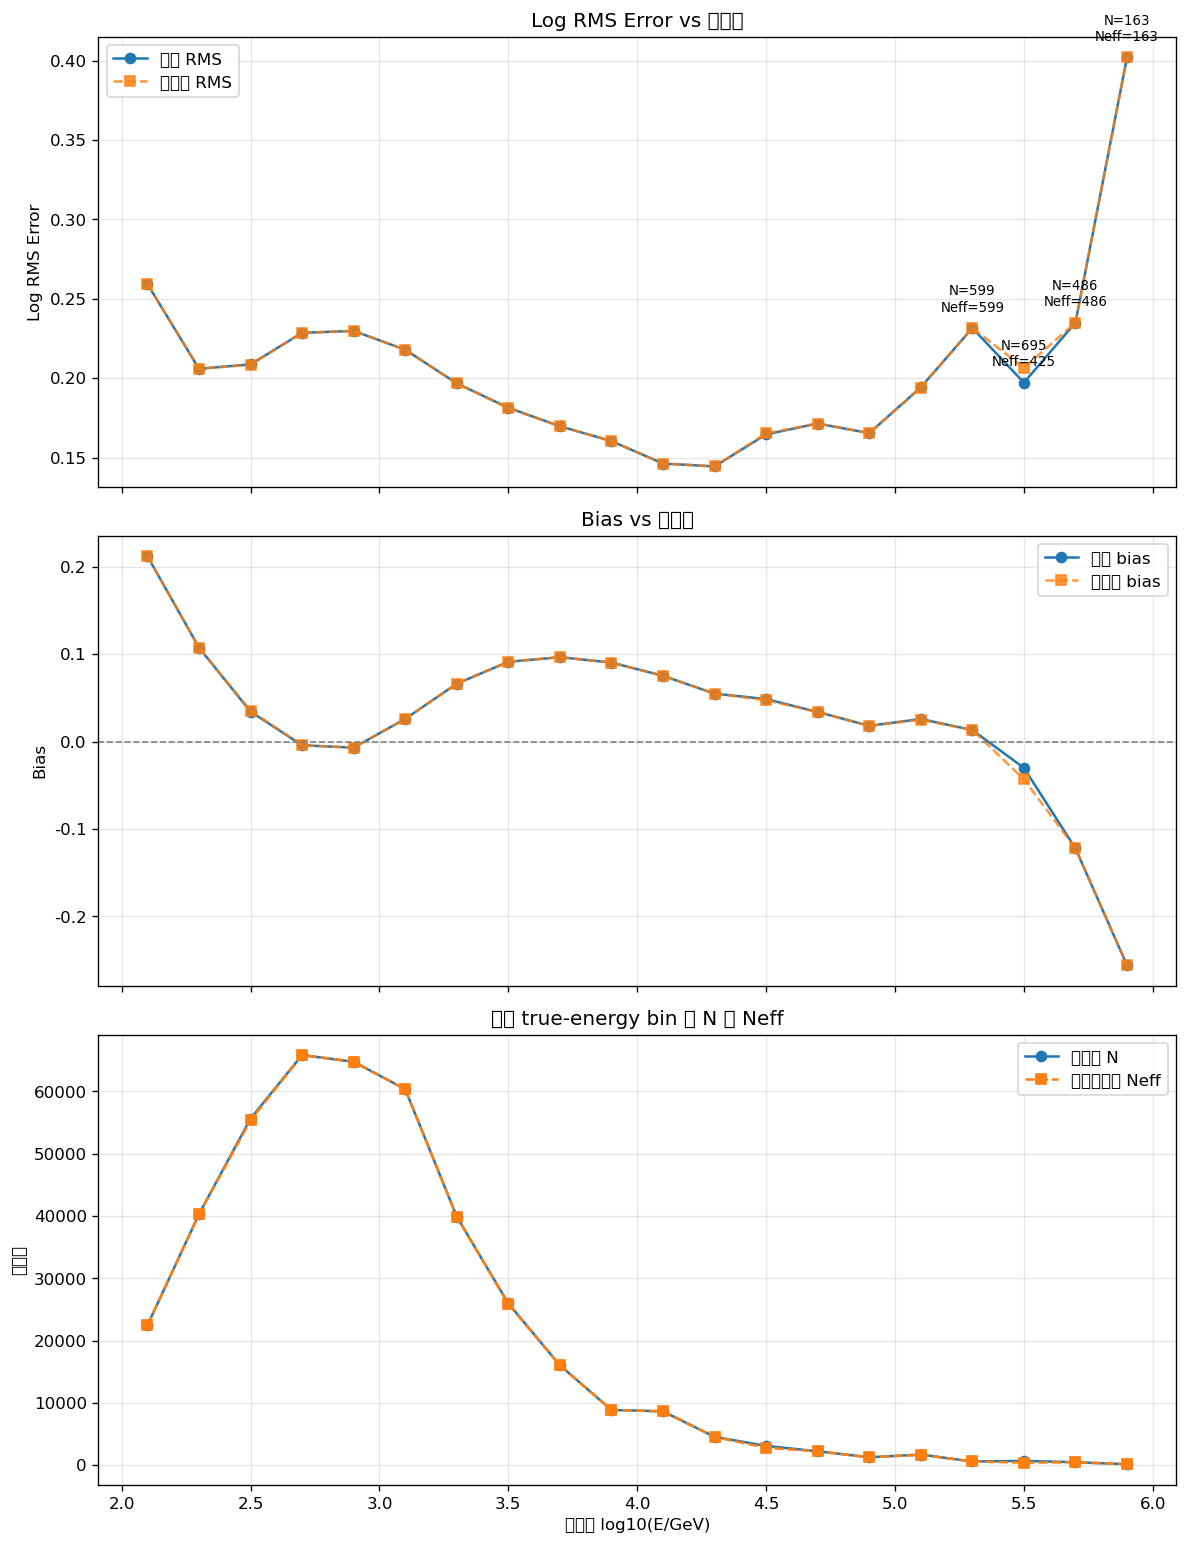

图已保存: /home/server/projects/energy_reconstruction/notebook/high_energy_resolution_diagnosis_figs/C_resolution_bias_counts.png


In [4]:
# 分 bin 统计函数与基线曲线复现
with open(RUN_DIR / "config.json", "r", encoding="utf-8") as f:
    config = json.load(f)
with open(RUN_DIR / "fig" / "metrics.json", "r", encoding="utf-8") as f:
    metrics_meta = json.load(f)

NBINS = 20
BIN_EDGES = np.linspace(frame["logE_true"].min(), frame["logE_true"].max(), NBINS + 1)
BIN_CENTERS = 0.5 * (BIN_EDGES[:-1] + BIN_EDGES[1:])

print(f"采用的 true-energy 分 bin 数: {NBINS}")
print("分 bin 来源说明: 原评估绘图代码 src/common/utils.py 默认 bins=20，且在 logE_true 范围内做等宽划分。")
print("bin edges:")
print(BIN_EDGES)


def weighted_mean(x, w):
    x = np.asarray(x, dtype=np.float64)
    w = np.asarray(w, dtype=np.float64)
    s = np.sum(w)
    return np.nan if s <= 0 else float(np.sum(w * x) / s)


def weighted_rms(x, w):
    x = np.asarray(x, dtype=np.float64)
    w = np.asarray(w, dtype=np.float64)
    s = np.sum(w)
    return np.nan if s <= 0 else float(np.sqrt(np.sum(w * x * x) / s))


def mad_sigma(x):
    x = np.asarray(x, dtype=np.float64)
    med = np.median(x)
    return float(1.4826 * np.median(np.abs(x - med)))


def assign_bins(values, edges):
    idx = np.digitize(values, edges) - 1
    idx[values == edges[-1]] = len(edges) - 2
    idx[(values < edges[0]) | (values > edges[-1])] = -1
    return idx


frame["true_bin"] = assign_bins(frame["logE_true"].to_numpy(), BIN_EDGES)

stats_rows = []
for i in range(NBINS):
    part = frame.loc[frame["true_bin"] == i].copy()
    label = f"[{BIN_EDGES[i]:.3f}, {BIN_EDGES[i + 1]:.3f})"
    if len(part) == 0:
        stats_rows.append(
            {
                "bin_id": i,
                "bin_label": label,
                "bin_left": BIN_EDGES[i],
                "bin_right": BIN_EDGES[i + 1],
                "bin_center": BIN_CENTERS[i],
                "N": 0,
                "sum_w": 0.0,
                "Neff": 0.0,
                "bias_unweighted": np.nan,
                "bias_weighted": np.nan,
                "rms_unweighted": np.nan,
                "rms_weighted": np.nan,
                "median_residual": np.nan,
                "robust68_halfwidth": np.nan,
                "iqr_sigma": np.nan,
                "mad_sigma": np.nan,
            }
        )
        continue

    residual = part["residual"].to_numpy()
    weight = part["weight"].to_numpy()
    q16, q50, q84 = np.quantile(residual, [0.16, 0.50, 0.84])
    iqr_sigma_val = (np.quantile(residual, 0.75) - np.quantile(residual, 0.25)) / 1.349
    neff = (weight.sum() ** 2) / np.sum(weight ** 2)

    stats_rows.append(
        {
            "bin_id": i,
            "bin_label": label,
            "bin_left": BIN_EDGES[i],
            "bin_right": BIN_EDGES[i + 1],
            "bin_center": BIN_CENTERS[i],
            "N": int(len(part)),
            "sum_w": float(weight.sum()),
            "Neff": float(neff),
            "bias_unweighted": float(np.mean(residual)),
            "bias_weighted": weighted_mean(residual, weight),
            "rms_unweighted": float(np.sqrt(np.mean(residual ** 2))),
            "rms_weighted": weighted_rms(residual, weight),
            "median_residual": float(q50),
            "robust68_halfwidth": float((q84 - q16) / 2.0),
            "iqr_sigma": float(iqr_sigma_val),
            "mad_sigma": mad_sigma(residual),
        }
    )

bin_stats = pd.DataFrame(stats_rows)
display(bin_stats)

high_tail = bin_stats[bin_stats["N"] > 0].tail(4).copy()
print("高能端最后 4 个有效 bin 的统计量：")
display(high_tail[["bin_label", "N", "Neff", "sum_w", "bias_weighted", "rms_weighted", "robust68_halfwidth"]])

fig, axes = plt.subplots(3, 1, figsize=(10, 13), sharex=True)

axes[0].plot(bin_stats["bin_center"], bin_stats["rms_weighted"], "o-", label="加权 RMS")
axes[0].plot(bin_stats["bin_center"], bin_stats["rms_unweighted"], "s--", label="非加权 RMS", alpha=0.8)
axes[0].set_ylabel("Log RMS Error")
axes[0].set_title("Log RMS Error vs 真能量")
axes[0].grid(alpha=0.3)
axes[0].legend()
for _, row in high_tail.iterrows():
    axes[0].annotate(
        f"N={int(row['N'])}\nNeff={row['Neff']:.0f}",
        (row["bin_center"], row["rms_weighted"]),
        xytext=(0, 10),
        textcoords="offset points",
        ha="center",
        fontsize=8,
    )

axes[1].plot(bin_stats["bin_center"], bin_stats["bias_weighted"], "o-", label="加权 bias")
axes[1].plot(bin_stats["bin_center"], bin_stats["bias_unweighted"], "s--", label="非加权 bias", alpha=0.8)
axes[1].axhline(0, color="gray", linestyle="--", linewidth=1)
axes[1].set_ylabel("Bias")
axes[1].set_title("Bias vs 真能量")
axes[1].grid(alpha=0.3)
axes[1].legend()

axes[2].plot(bin_stats["bin_center"], bin_stats["N"], "o-", label="事件数 N")
axes[2].plot(bin_stats["bin_center"], bin_stats["Neff"], "s--", label="有效统计量 Neff")
axes[2].set_xlabel("真能量 log10(E/GeV)")
axes[2].set_ylabel("统计量")
axes[2].set_title("每个 true-energy bin 的 N 与 Neff")
axes[2].grid(alpha=0.3)
axes[2].legend()

fig.tight_layout()
fig_path = FIG_DIR / "C_resolution_bias_counts.png"
fig.savefig(fig_path, bbox_inches="tight")
plt.show()
print(f"图已保存: {fig_path}")

## D. 检查高能端回升是否由统计不足造成

这一节聚焦最高能的最后几个 true-energy bin，检查：

- `N` 与 `Neff` 是否过低
- residual 分布是否被少量离群点拉宽
- 稳健散度指标是否也同步恶化

如果 `RMS` 明显变差，但稳健指标变化不大，那么高能回升更可能是少数离群点驱动，而不是整体分布都变差。

最高能端最后 4 个有效 bin 的详细统计：


,bin_id,bin_label,N,Neff,均值,中位数,标准差,RMS,q16,q50,q84,68%半宽,IQR/1.349,MAD*1.4826
0,16,"[5.199, 5.399)",599,599.000000,0.013258,0.024425,0.231242,0.231622,-0.180768,0.024425,0.223062,0.201915,0.212355,0.211794
1,17,"[5.399, 5.599)",695,425.058139,-0.043198,-0.014208,0.202027,0.206594,-0.217877,-0.014208,0.124769,0.171323,0.163910,0.156446
2,18,"[5.599, 5.799)",486,486.000000,-0.122255,-0.097425,0.200707,0.235009,-0.268543,-0.097425,0.034391,0.151467,0.146075,0.145743
3,19,"[5.799, 5.999)",163,163.000000,-0.256091,-0.204391,0.310002,0.402099,-0.338599,-0.204391,-0.097268,0.120665,0.121701,0.115229


/tmp/ipykernel_1449573/2486631664.py:50: UserWarning: Glyph 35745 (\N{CJK UNIFIED IDEOGRAPH-8BA1}) missing from current font.
  fig.tight_layout()
/tmp/ipykernel_1449573/2486631664.py:50: UserWarning: Glyph 25968 (\N{CJK UNIFIED IDEOGRAPH-6570}) missing from current font.
  fig.tight_layout()
/tmp/ipykernel_1449573/2486631664.py:50: UserWarning: Glyph 39640 (\N{CJK UNIFIED IDEOGRAPH-9AD8}) missing from current font.
  fig.tight_layout()
/tmp/ipykernel_1449573/2486631664.py:50: UserWarning: Glyph 33021 (\N{CJK UNIFIED IDEOGRAPH-80FD}) missing from current font.
  fig.tight_layout()
/tmp/ipykernel_1449573/2486631664.py:50: UserWarning: Glyph 30452 (\N{CJK UNIFIED IDEOGRAPH-76F4}) missing from current font.
  fig.tight_layout()
/tmp/ipykernel_1449573/2486631664.py:50: UserWarning: Glyph 26041 (\N{CJK UNIFIED IDEOGRAPH-65B9}) missing from current font.
  fig.tight_layout()
/tmp/ipykernel_1449573/2486631664.py:50: UserWarning: Glyph 22270 (\N{CJK UNIFIED IDEOGRAPH-56FE}) missing from curren

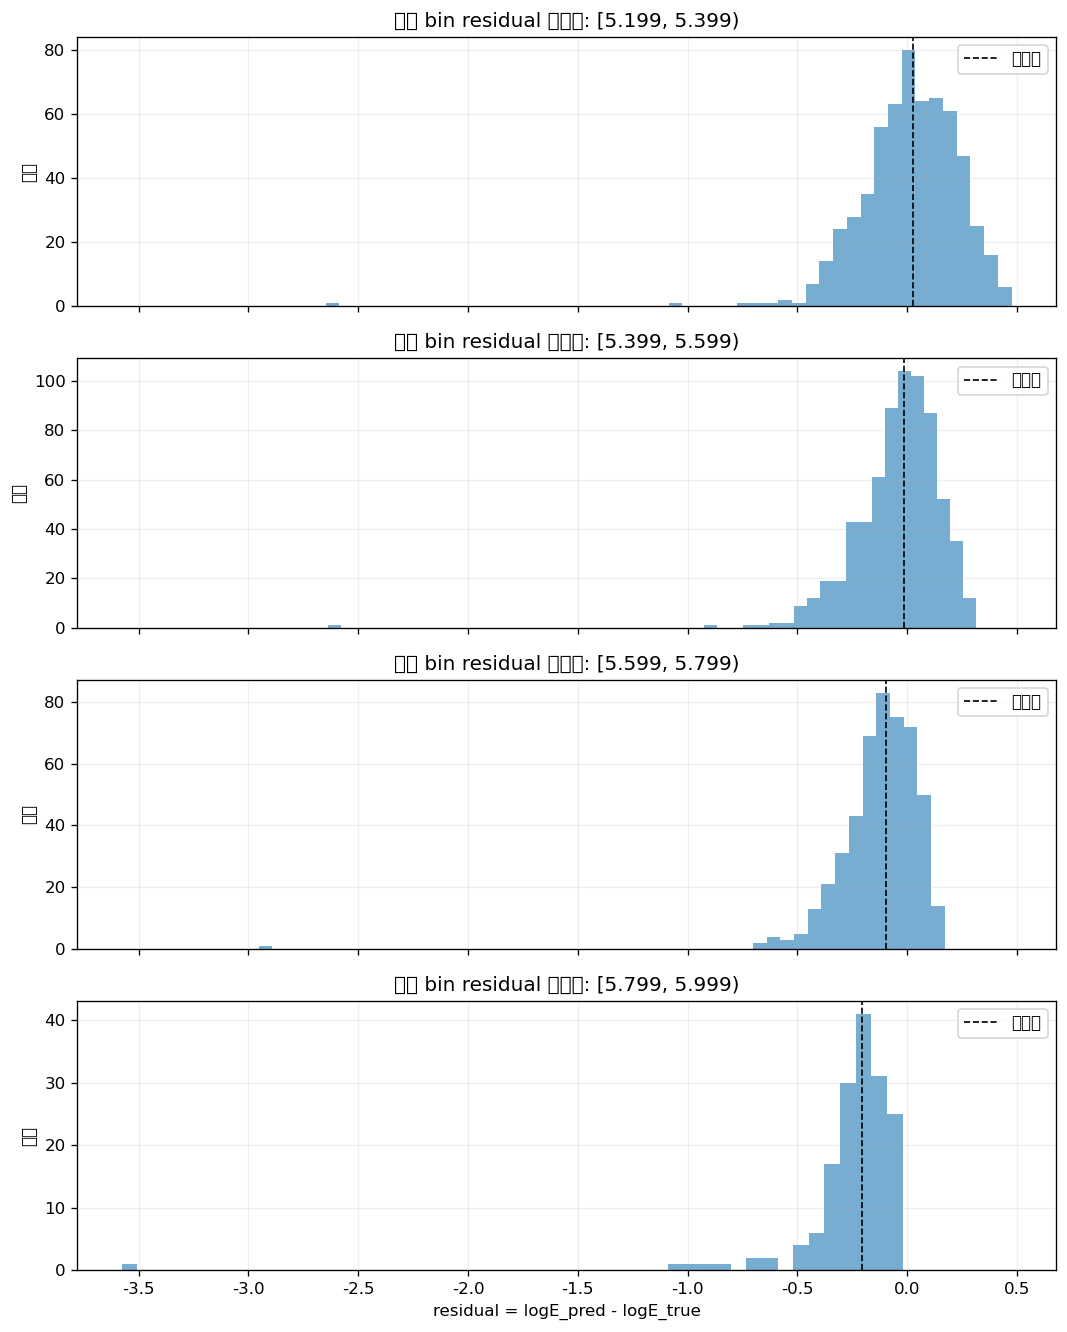

图已保存: /home/server/projects/energy_reconstruction/notebook/high_energy_resolution_diagnosis_figs/D_high_energy_residual_histograms.png


/tmp/ipykernel_1449573/2486631664.py:64: UserWarning: Glyph 30495 (\N{CJK UNIFIED IDEOGRAPH-771F}) missing from current font.
  fig.tight_layout()
/tmp/ipykernel_1449573/2486631664.py:64: UserWarning: Glyph 33021 (\N{CJK UNIFIED IDEOGRAPH-80FD}) missing from current font.
  fig.tight_layout()
/tmp/ipykernel_1449573/2486631664.py:64: UserWarning: Glyph 37327 (\N{CJK UNIFIED IDEOGRAPH-91CF}) missing from current font.
  fig.tight_layout()
/tmp/ipykernel_1449573/2486631664.py:64: UserWarning: Glyph 39640 (\N{CJK UNIFIED IDEOGRAPH-9AD8}) missing from current font.
  fig.tight_layout()
/tmp/ipykernel_1449573/2486631664.py:64: UserWarning: Glyph 30340 (\N{CJK UNIFIED IDEOGRAPH-7684}) missing from current font.
  fig.tight_layout()
/tmp/ipykernel_1449573/2486631664.py:64: UserWarning: Glyph 31665 (\N{CJK UNIFIED IDEOGRAPH-7BB1}) missing from current font.
  fig.tight_layout()
/tmp/ipykernel_1449573/2486631664.py:64: UserWarning: Glyph 32447 (\N{CJK UNIFIED IDEOGRAPH-7EBF}) missing from curren

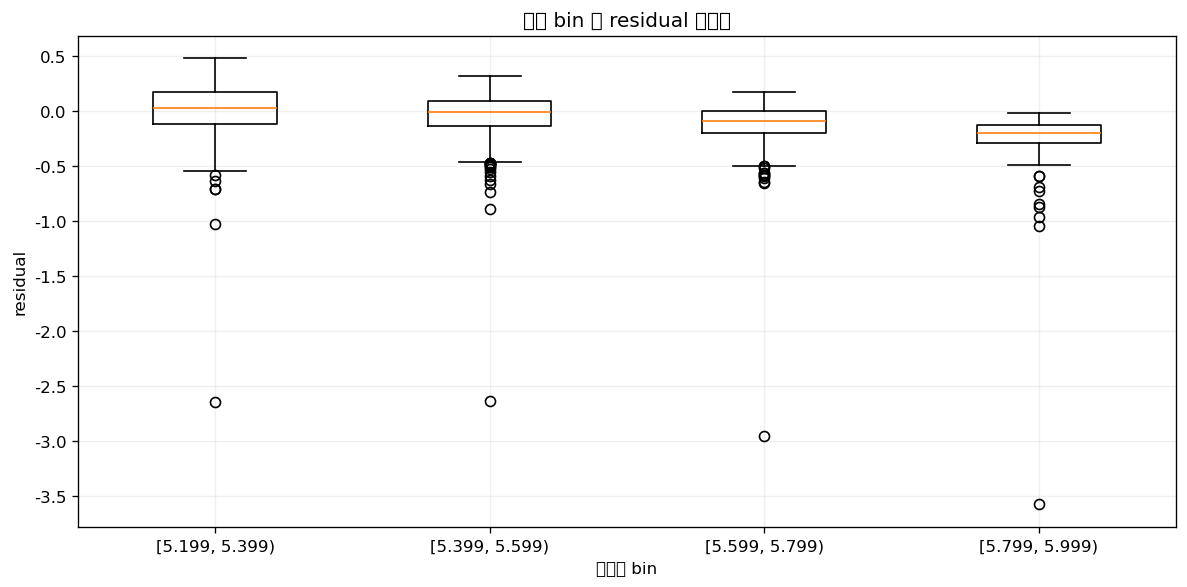

/tmp/ipykernel_1449573/2486631664.py:80: UserWarning: Glyph 30495 (\N{CJK UNIFIED IDEOGRAPH-771F}) missing from current font.
  fig.tight_layout()
/tmp/ipykernel_1449573/2486631664.py:80: UserWarning: Glyph 33021 (\N{CJK UNIFIED IDEOGRAPH-80FD}) missing from current font.
  fig.tight_layout()
/tmp/ipykernel_1449573/2486631664.py:80: UserWarning: Glyph 37327 (\N{CJK UNIFIED IDEOGRAPH-91CF}) missing from current font.
  fig.tight_layout()


图已保存: /home/server/projects/energy_reconstruction/notebook/high_energy_resolution_diagnosis_figs/D_high_energy_residual_boxplot.png


/tmp/ipykernel_1449573/2486631664.py:80: UserWarning: Glyph 25955 (\N{CJK UNIFIED IDEOGRAPH-6563}) missing from current font.
  fig.tight_layout()
/tmp/ipykernel_1449573/2486631664.py:80: UserWarning: Glyph 24230 (\N{CJK UNIFIED IDEOGRAPH-5EA6}) missing from current font.
  fig.tight_layout()
/tmp/ipykernel_1449573/2486631664.py:80: UserWarning: Glyph 23610 (\N{CJK UNIFIED IDEOGRAPH-5C3A}) missing from current font.
  fig.tight_layout()
/tmp/ipykernel_1449573/2486631664.py:80: UserWarning: Glyph 19982 (\N{CJK UNIFIED IDEOGRAPH-4E0E}) missing from current font.
  fig.tight_layout()
/tmp/ipykernel_1449573/2486631664.py:80: UserWarning: Glyph 31283 (\N{CJK UNIFIED IDEOGRAPH-7A33}) missing from current font.
  fig.tight_layout()
/tmp/ipykernel_1449573/2486631664.py:80: UserWarning: Glyph 20581 (\N{CJK UNIFIED IDEOGRAPH-5065}) missing from current font.
  fig.tight_layout()
/tmp/ipykernel_1449573/2486631664.py:80: UserWarning: Glyph 25351 (\N{CJK UNIFIED IDEOGRAPH-6307}) missing from curren

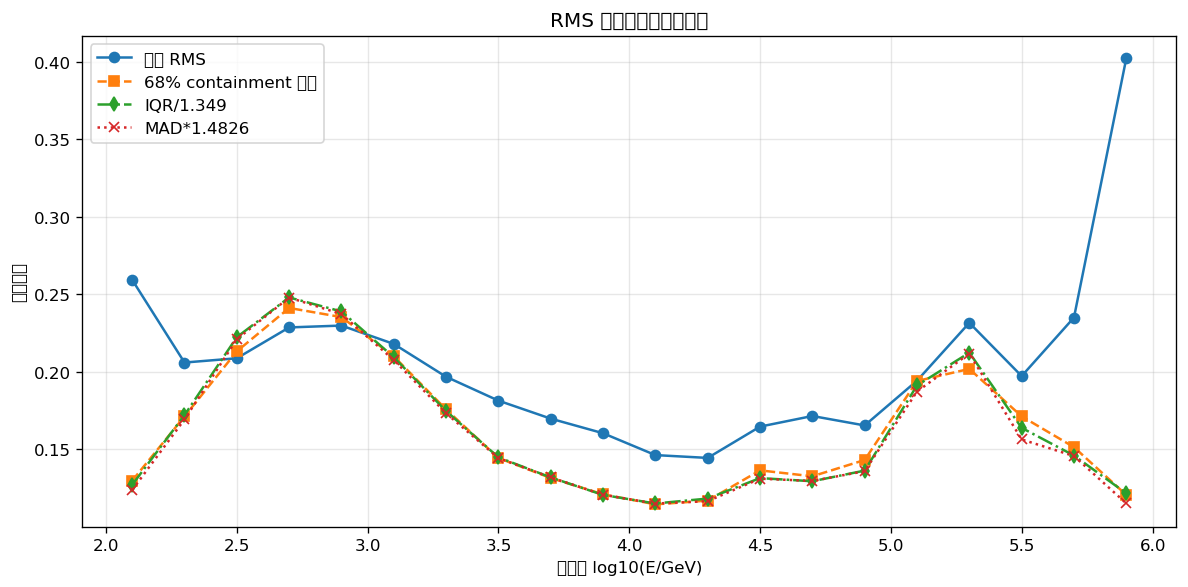

图已保存: /home/server/projects/energy_reconstruction/notebook/high_energy_resolution_diagnosis_figs/D_rms_vs_robust_spread.png
自动诊断结论：
高能回升更可能由少数离群点驱动，因为 RMS 变差明显，而稳健散度指标变化较小。


In [5]:
# 高能端详细统计、分布图与稳健指标对比
high_bins = bin_stats[bin_stats["N"] > 0].tail(4)["bin_id"].tolist()
high_bin_frames = []
detail_rows = []

for bin_id in high_bins:
    part = frame.loc[frame["true_bin"] == bin_id].copy()
    residual = part["residual"].to_numpy()
    weight = part["weight"].to_numpy()
    q16, q50, q84 = np.quantile(residual, [0.16, 0.50, 0.84])
    detail_rows.append(
        {
            "bin_id": int(bin_id),
            "bin_label": bin_stats.loc[bin_stats["bin_id"] == bin_id, "bin_label"].iloc[0],
            "N": int(len(part)),
            "Neff": float((weight.sum() ** 2) / np.sum(weight ** 2)),
            "均值": float(np.mean(residual)),
            "中位数": float(np.median(residual)),
            "标准差": float(np.std(residual)),
            "RMS": float(np.sqrt(np.mean(residual ** 2))),
            "q16": float(q16),
            "q50": float(q50),
            "q84": float(q84),
            "68%半宽": float((q84 - q16) / 2.0),
            "IQR/1.349": float((np.quantile(residual, 0.75) - np.quantile(residual, 0.25)) / 1.349),
            "MAD*1.4826": mad_sigma(residual),
        }
    )
    part["bin_label"] = detail_rows[-1]["bin_label"]
    high_bin_frames.append(part)

high_detail_df = pd.DataFrame(detail_rows)
print("最高能端最后 4 个有效 bin 的详细统计：")
display(high_detail_df)

if high_bin_frames:
    fig, axes = plt.subplots(len(high_bins), 1, figsize=(9, 2.8 * len(high_bins)), sharex=True)
    if len(high_bins) == 1:
        axes = [axes]
    for ax, bin_id in zip(axes, high_bins):
        part = frame.loc[frame["true_bin"] == bin_id]
        label = bin_stats.loc[bin_stats["bin_id"] == bin_id, "bin_label"].iloc[0]
        ax.hist(part["residual"], bins=50, histtype="stepfilled", alpha=0.6)
        ax.axvline(np.median(part["residual"]), color="black", linestyle="--", linewidth=1, label="中位数")
        ax.set_title(f"高能 bin residual 直方图: {label}")
        ax.set_ylabel("计数")
        ax.grid(alpha=0.2)
        ax.legend()
    axes[-1].set_xlabel("residual = logE_pred - logE_true")
    fig.tight_layout()
    fig_path = FIG_DIR / "D_high_energy_residual_histograms.png"
    fig.savefig(fig_path, bbox_inches="tight")
    plt.show()
    print(f"图已保存: {fig_path}")

    fig, ax = plt.subplots(figsize=(10, 5))
    grouped = [frame.loc[frame["true_bin"] == bin_id, "residual"].to_numpy() for bin_id in high_bins]
    labels = [bin_stats.loc[bin_stats["bin_id"] == bin_id, "bin_label"].iloc[0] for bin_id in high_bins]
    ax.boxplot(grouped, labels=labels, showfliers=True)
    ax.set_title("高能 bin 的 residual 箱线图")
    ax.set_xlabel("真能量 bin")
    ax.set_ylabel("residual")
    ax.grid(alpha=0.2)
    fig.tight_layout()
    fig_path = FIG_DIR / "D_high_energy_residual_boxplot.png"
    fig.savefig(fig_path, bbox_inches="tight")
    plt.show()
    print(f"图已保存: {fig_path}")

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(bin_stats["bin_center"], bin_stats["rms_weighted"], "o-", label="加权 RMS")
ax.plot(bin_stats["bin_center"], bin_stats["robust68_halfwidth"], "s--", label="68% containment 半宽")
ax.plot(bin_stats["bin_center"], bin_stats["iqr_sigma"], "d-.", label="IQR/1.349")
ax.plot(bin_stats["bin_center"], bin_stats["mad_sigma"], "x:", label="MAD*1.4826")
ax.set_title("RMS 与稳健散度指标对比")
ax.set_xlabel("真能量 log10(E/GeV)")
ax.set_ylabel("散度尺度")
ax.grid(alpha=0.3)
ax.legend()
fig.tight_layout()
fig_path = FIG_DIR / "D_rms_vs_robust_spread.png"
fig.savefig(fig_path, bbox_inches="tight")
plt.show()
print(f"图已保存: {fig_path}")

valid_bins = bin_stats[bin_stats["N"] > 0].copy()
if len(valid_bins) >= 6:
    prev_ref = valid_bins.iloc[-6:-3]
    high_ref = valid_bins.iloc[-3:]
    rms_ratio = high_ref["rms_weighted"].mean() / prev_ref["rms_weighted"].mean()
    robust_ratio = high_ref["robust68_halfwidth"].mean() / prev_ref["robust68_halfwidth"].mean()
    if rms_ratio > 1.08 and robust_ratio < 1.03:
        diagnosis_text = "高能回升更可能由少数离群点驱动，因为 RMS 变差明显，而稳健散度指标变化较小。"
    elif rms_ratio > 1.08 and robust_ratio > 1.08:
        diagnosis_text = "高能回升不仅体现在 RMS，也体现在稳健指标上，说明分布整体确实变宽。"
    else:
        diagnosis_text = "高能端未见很强的额外展宽证据，回升幅度可能有限，需结合 Neff 与 bias 一起判断。"
else:
    diagnosis_text = "有效高能 bin 数不足，无法做稳定的前后段对比。"

print("自动诊断结论：")
print(diagnosis_text)

## E. 检查是否存在系统性偏差

这里检查 residual 随真能量的变化是否出现系统性偏移，尤其关注高能端是否出现：

- 系统性低估：bias 变为明显负值
- 系统性高估：bias 变为明显正值

如果高能端 bias 明显偏移，说明模型在高能稀疏区域可能出现外推失败，或者发生了回归到均值。

/tmp/ipykernel_1449573/2483816007.py:21: UserWarning: Glyph 30495 (\N{CJK UNIFIED IDEOGRAPH-771F}) missing from current font.
  fig.tight_layout()
/tmp/ipykernel_1449573/2483816007.py:21: UserWarning: Glyph 33021 (\N{CJK UNIFIED IDEOGRAPH-80FD}) missing from current font.
  fig.tight_layout()
/tmp/ipykernel_1449573/2483816007.py:21: UserWarning: Glyph 37327 (\N{CJK UNIFIED IDEOGRAPH-91CF}) missing from current font.
  fig.tight_layout()
/tmp/ipykernel_1449573/2483816007.py:21: UserWarning: Glyph 30340 (\N{CJK UNIFIED IDEOGRAPH-7684}) missing from current font.
  fig.tight_layout()
/tmp/ipykernel_1449573/2483816007.py:21: UserWarning: Glyph 22270 (\N{CJK UNIFIED IDEOGRAPH-56FE}) missing from current font.
  fig.tight_layout()
/tmp/ipykernel_1449573/2483816007.py:21: UserWarning: Glyph 35745 (\N{CJK UNIFIED IDEOGRAPH-8BA1}) missing from current font.
  fig.tight_layout()
/tmp/ipykernel_1449573/2483816007.py:21: UserWarning: Glyph 25968 (\N{CJK UNIFIED IDEOGRAPH-6570}) missing from curren

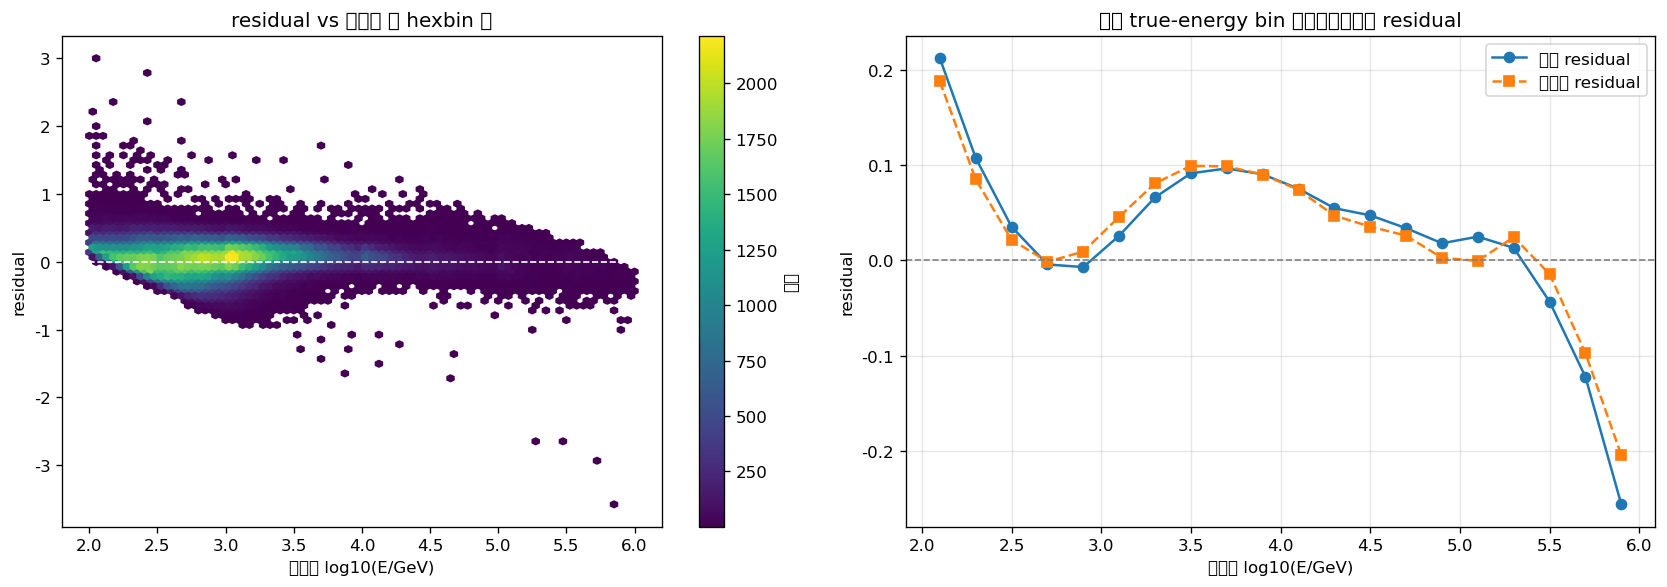

图已保存: /home/server/projects/energy_reconstruction/notebook/high_energy_resolution_diagnosis_figs/E_residual_bias_diagnosis.png
自动偏差判断：
高能端存在较明显的系统性低估，说明模型可能在高能稀疏区发生外推失败或向均值回归。
最后 3 个有效高能 bin 的平均加权 bias = -0.1361
最后 3 个有效高能 bin 的平均中位数 residual = -0.1053


In [6]:
# residual vs true energy 与高能 bias 检查
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

hb = axes[0].hexbin(frame["logE_true"], frame["residual"], gridsize=80, mincnt=1, cmap="viridis")
axes[0].axhline(0, color="white", linestyle="--", linewidth=1)
axes[0].set_title("residual vs 真能量 的 hexbin 图")
axes[0].set_xlabel("真能量 log10(E/GeV)")
axes[0].set_ylabel("residual")
cb = fig.colorbar(hb, ax=axes[0])
cb.set_label("计数")

axes[1].plot(bin_stats["bin_center"], bin_stats["bias_unweighted"], "o-", label="均值 residual")
axes[1].plot(bin_stats["bin_center"], bin_stats["median_residual"], "s--", label="中位数 residual")
axes[1].axhline(0, color="gray", linestyle="--", linewidth=1)
axes[1].set_title("每个 true-energy bin 的均值与中位数 residual")
axes[1].set_xlabel("真能量 log10(E/GeV)")
axes[1].set_ylabel("residual")
axes[1].grid(alpha=0.3)
axes[1].legend()

fig.tight_layout()
fig_path = FIG_DIR / "E_residual_bias_diagnosis.png"
fig.savefig(fig_path, bbox_inches="tight")
plt.show()
print(f"图已保存: {fig_path}")

high_bias = bin_stats[bin_stats["N"] > 0].tail(3)
mean_high_bias = high_bias["bias_weighted"].mean()
median_high_bias = high_bias["median_residual"].mean()
if mean_high_bias < -0.03:
    bias_judgement = "高能端存在较明显的系统性低估，说明模型可能在高能稀疏区发生外推失败或向均值回归。"
elif mean_high_bias > 0.03:
    bias_judgement = "高能端存在较明显的系统性高估，说明模型在高能区可能出现系统偏移。"
else:
    bias_judgement = "高能端未见很强的系统性均值偏移，bias 不是主导问题。"

print("自动偏差判断：")
print(bias_judgement)
print(f"最后 3 个有效高能 bin 的平均加权 bias = {mean_high_bias:.4f}")
print(f"最后 3 个有效高能 bin 的平均中位数 residual = {median_high_bias:.4f}")

## F. 检查几何条件是否导致高能端变差

如果数据中存在这些字段，就对高能端做条件分析：

- `theta`
- `nhit / nv`
- `dcedge / dcore / edge`

具体做法：在最后几个 true-energy bin 内，再按几何条件分组比较 residual 分布与 RMS。如果相关字段缺失，自动跳过，并说明原因。

In [7]:
# 几何条件切分分析
geom_available = [col for col in ["theta", "nhit", "edge"] if col in frame.columns]
high_energy_mask = frame["true_bin"].isin(high_bins)
high_energy_df = frame.loc[high_energy_mask].copy()

if not geom_available:
    print("该项分析因缺少可用几何字段未执行。")
    print("当前可用列:")
    print(list(frame.columns))
    print("字段跳过原因:")
    pprint(skipped_extra_fields)
else:
    def compare_by_split(df_in, column, title, out_name):
        valid = df_in[[column, "residual", "weight"]].dropna().copy()
        if len(valid) < 20:
            print(f"{column} 可用样本过少，跳过。")
            return None
        threshold = valid[column].median()
        valid["group"] = np.where(valid[column] <= threshold, f"{column} 较小", f"{column} 较大")
        rows = []
        for group_name, sub in valid.groupby("group"):
            residual = sub["residual"].to_numpy()
            weight = sub["weight"].to_numpy()
            rows.append(
                {
                    "分组": group_name,
                    "样本数": len(sub),
                    "Neff": (weight.sum() ** 2) / np.sum(weight ** 2),
                    "加权RMS": weighted_rms(residual, weight),
                    "加权bias": weighted_mean(residual, weight),
                    "68%半宽": (np.quantile(residual, 0.84) - np.quantile(residual, 0.16)) / 2.0,
                }
            )
        out_df = pd.DataFrame(rows)
        display(out_df)

        fig, axes = plt.subplots(1, 2, figsize=(12, 4))
        axes[0].bar(out_df["分组"], out_df["加权RMS"])
        axes[0].set_title(f"{title}: 加权 RMS 对比")
        axes[0].set_ylabel("加权 RMS")
        axes[0].grid(alpha=0.2)
        axes[1].bar(out_df["分组"], out_df["加权bias"])
        axes[1].set_title(f"{title}: 加权 bias 对比")
        axes[1].set_ylabel("加权 bias")
        axes[1].grid(alpha=0.2)
        fig.tight_layout()
        fig_path = FIG_DIR / out_name
        fig.savefig(fig_path, bbox_inches="tight")
        plt.show()
        print(f"图已保存: {fig_path}")
        return out_df

    geom_results = {}
    if "theta" in geom_available:
        geom_results["theta"] = compare_by_split(high_energy_df, "theta", "高能端按 theta 分组", "F_theta_split.png")
    if "edge" in geom_available:
        geom_results["edge"] = compare_by_split(high_energy_df, "edge", "高能端按边缘变量分组", "F_edge_split.png")
    if "nhit" in geom_available:
        geom_results["nhit"] = compare_by_split(high_energy_df, "nhit", "高能端按 nhit 分组", "F_nhit_split.png")

    print("几何条件分析完成。若某一组的加权 RMS 明显更高，则说明高能回升可能主要来自该类几何条件较差的事件。")

该项分析因缺少可用几何字段未执行。
当前可用列:
['logE_true', 'logE_pred', 'residual', 'weight', 'true_bin']
字段跳过原因:
{'edge': '未发现对应字段。',
 'nhit': '未发现对应字段。',
 'theta': '字段 costheta 长度为 193，与主表长度 423617 不一致，因此本项分析跳过。'}


## G. 检查权重是否导致 mc-weighted RMS 被放大

这里直接比较：

- 非加权 RMS vs true energy
- 加权 RMS vs true energy
- 非加权 bias vs true energy
- 加权 bias vs true energy

同时检查高能端是否存在少数高权重点。如果高能端视觉上的“回升”主要出现在加权曲线上，而非加权曲线较平稳，则说明权重放大是重要原因。

/tmp/ipykernel_1449573/3839889262.py:21: UserWarning: Glyph 30495 (\N{CJK UNIFIED IDEOGRAPH-771F}) missing from current font.
  fig.tight_layout()
/tmp/ipykernel_1449573/3839889262.py:21: UserWarning: Glyph 33021 (\N{CJK UNIFIED IDEOGRAPH-80FD}) missing from current font.
  fig.tight_layout()
/tmp/ipykernel_1449573/3839889262.py:21: UserWarning: Glyph 37327 (\N{CJK UNIFIED IDEOGRAPH-91CF}) missing from current font.
  fig.tight_layout()
/tmp/ipykernel_1449573/3839889262.py:21: UserWarning: Glyph 39640 (\N{CJK UNIFIED IDEOGRAPH-9AD8}) missing from current font.
  fig.tight_layout()
/tmp/ipykernel_1449573/3839889262.py:21: UserWarning: Glyph 31471 (\N{CJK UNIFIED IDEOGRAPH-7AEF}) missing from current font.
  fig.tight_layout()
/tmp/ipykernel_1449573/3839889262.py:21: UserWarning: Glyph 21069 (\N{CJK UNIFIED IDEOGRAPH-524D}) missing from current font.
  fig.tight_layout()
/tmp/ipykernel_1449573/3839889262.py:21: UserWarning: Glyph 21518 (\N{CJK UNIFIED IDEOGRAPH-540E}) missing from curren

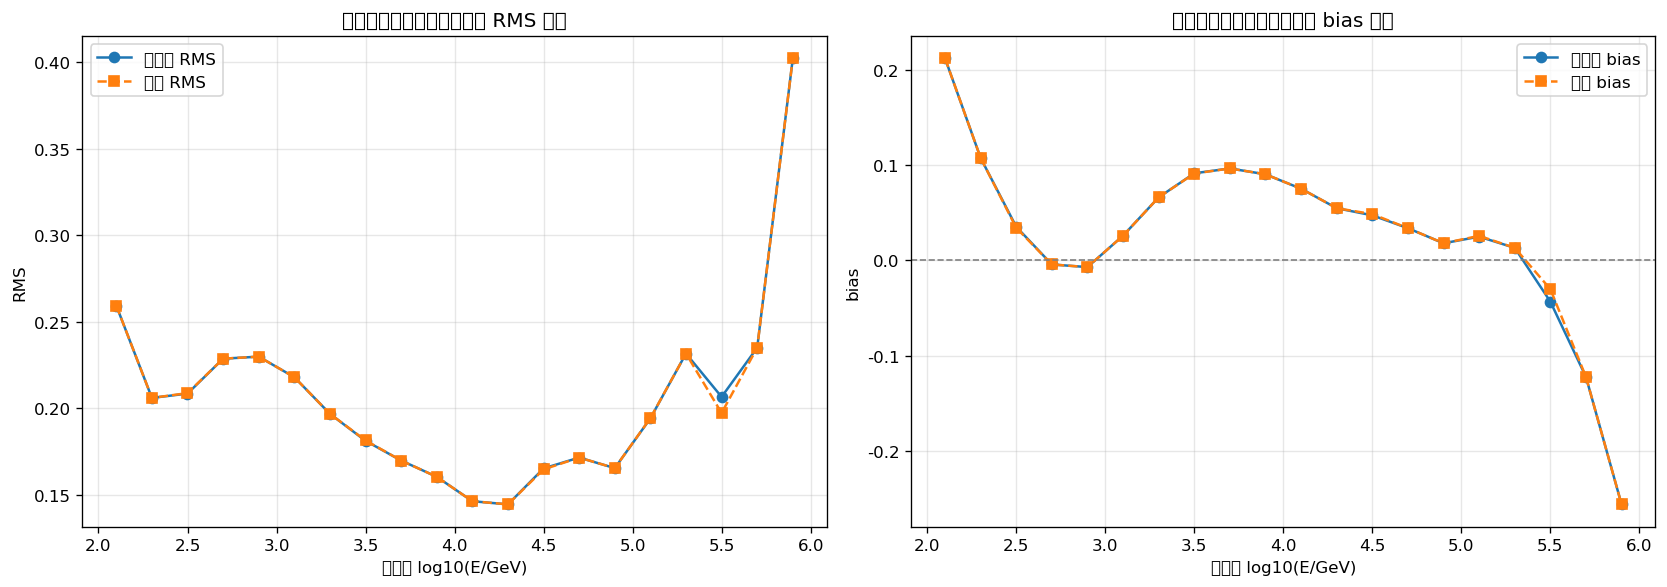

图已保存: /home/server/projects/energy_reconstruction/notebook/high_energy_resolution_diagnosis_figs/G_weighted_vs_unweighted.png
高能端最高权重事件示例：


,logE_true,logE_pred,residual,weight
91,5.701023,5.642599,-0.058424,0.016006
289707,5.785466,5.578291,-0.207175,0.016006
283626,5.622936,5.707298,0.084362,0.016006
283693,5.798573,5.448308,-0.350265,0.016006
283763,5.778294,5.193389,-0.584905,0.016006
283764,5.646814,5.699394,0.052580,0.016006
284051,5.730311,5.489447,-0.240865,0.016006
284251,5.631538,5.665944,0.034406,0.016006
284384,5.633489,5.550239,-0.083251,0.016006
284680,5.686313,5.512886,-0.173428,0.016006


自动权重判断：
加权与非加权曲线差异较小，说明高能回升不太像是权重视觉放大造成的。
高能端最大权重 / 中位权重 = 1.000


In [8]:
# 权重影响分析与高权重点检查
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(bin_stats["bin_center"], bin_stats["rms_unweighted"], "o-", label="非加权 RMS")
axes[0].plot(bin_stats["bin_center"], bin_stats["rms_weighted"], "s--", label="加权 RMS")
axes[0].set_title("高能端前后：加权与非加权 RMS 对比")
axes[0].set_xlabel("真能量 log10(E/GeV)")
axes[0].set_ylabel("RMS")
axes[0].grid(alpha=0.3)
axes[0].legend()

axes[1].plot(bin_stats["bin_center"], bin_stats["bias_unweighted"], "o-", label="非加权 bias")
axes[1].plot(bin_stats["bin_center"], bin_stats["bias_weighted"], "s--", label="加权 bias")
axes[1].axhline(0, color="gray", linestyle="--", linewidth=1)
axes[1].set_title("高能端前后：加权与非加权 bias 对比")
axes[1].set_xlabel("真能量 log10(E/GeV)")
axes[1].set_ylabel("bias")
axes[1].grid(alpha=0.3)
axes[1].legend()

fig.tight_layout()
fig_path = FIG_DIR / "G_weighted_vs_unweighted.png"
fig.savefig(fig_path, bbox_inches="tight")
plt.show()
print(f"图已保存: {fig_path}")

high_tail_mask = frame["true_bin"].isin(high_bins[-2:]) if len(high_bins) >= 2 else frame["true_bin"].isin(high_bins)
high_tail_df = frame.loc[high_tail_mask].copy().sort_values("weight", ascending=False)

if len(high_tail_df) > 0:
    high_weight_df = high_tail_df.head(15).copy()
    aux_cols = [c for c in ["logE_true", "logE_pred", "residual", "weight", "nhit", "theta", "edge"] if c in high_weight_df.columns]
    print("高能端最高权重事件示例：")
    display(high_weight_df[aux_cols])

median_weight = float(high_tail_df["weight"].median()) if len(high_tail_df) else np.nan
max_weight = float(high_tail_df["weight"].max()) if len(high_tail_df) else np.nan
weight_ratio = max_weight / median_weight if len(high_tail_df) and median_weight > 0 else np.nan

high_tail_rms_gap = (bin_stats["rms_weighted"] - bin_stats["rms_unweighted"]).tail(3).mean()
if np.isfinite(weight_ratio) and weight_ratio > 3 and high_tail_rms_gap > 0.01:
    weight_text = "高能端存在少数高权重点，且加权 RMS 明显高于非加权 RMS，说明 mc_weight 对回升有放大作用。"
elif high_tail_rms_gap > 0.01:
    weight_text = "加权 RMS 高于非加权 RMS，但权重极端程度有限，说明权重有一定放大作用，但不一定是唯一原因。"
else:
    weight_text = "加权与非加权曲线差异较小，说明高能回升不太像是权重视觉放大造成的。"

print("自动权重判断：")
print(weight_text)
print(f"高能端最大权重 / 中位权重 = {weight_ratio:.3f}")

## H. 输出高能异常事件表

这里从最高能 bin 或最后两个高能 bin 中，找出 `|residual|` 最大的事件，导出到 CSV，方便后续人工追查。

In [9]:
# 导出高能异常事件表
if len(high_bins) >= 2:
    outlier_mask = frame["true_bin"].isin(high_bins[-2:])
else:
    outlier_mask = frame["true_bin"].isin(high_bins)

outliers = frame.loc[outlier_mask].copy()
outliers["abs_residual"] = outliers["residual"].abs()
outliers = outliers.sort_values("abs_residual", ascending=False)

keep_cols = [c for c in ["logE_true", "logE_pred", "residual", "weight", "nhit", "theta", "edge", "true_bin"] if c in outliers.columns]
outliers_to_save = outliers[keep_cols].head(200).copy()
outliers_to_save.to_csv(OUTLIER_CSV, index=False)

print(f"已导出高能异常事件表: {OUTLIER_CSV}")
display(outliers_to_save.head(20))

已导出高能异常事件表: /home/server/projects/energy_reconstruction/notebook/high_energy_outliers.csv


,logE_true,logE_pred,residual,weight,true_bin
310434,5.860125,2.283090,-3.577035,0.016006,19
412784,5.712586,2.759372,-2.953213,0.016006,18
348914,5.896617,4.849674,-1.046943,0.016006,19
217301,5.892058,4.921005,-0.971053,0.016006,19
173765,5.892919,5.016294,-0.876626,0.016006,19
299387,5.936350,5.085968,-0.850383,0.016006,19
249720,5.871950,5.144353,-0.727597,0.016006,19
36059,5.853748,5.161164,-0.692584,0.016006,19
2130,5.675922,5.021452,-0.654470,0.016006,18
253335,5.607539,4.956828,-0.650711,0.016006,18


## I. 最终结论汇总

这一节根据前面的统计量、稳健散度、bias、权重和几何条件分析，自动生成一份中文结论汇总。

In [10]:
# 自动生成中文结论汇总
valid_bins = bin_stats[bin_stats["N"] > 0].copy()
last3 = valid_bins.tail(3)
prev3 = valid_bins.iloc[-6:-3] if len(valid_bins) >= 6 else valid_bins.head(max(len(valid_bins) - 3, 1))

if len(last3) > 0 and len(prev3) > 0:
    rms_change = last3["rms_weighted"].mean() - prev3["rms_weighted"].mean()
    neff_last = last3["Neff"].mean()
    robust_change = last3["robust68_halfwidth"].mean() - prev3["robust68_halfwidth"].mean()
    bias_last = last3["bias_weighted"].mean()
    weight_gap = (last3["rms_weighted"] - last3["rms_unweighted"]).mean()
else:
    rms_change = np.nan
    neff_last = np.nan
    robust_change = np.nan
    bias_last = np.nan
    weight_gap = np.nan

if np.isfinite(rms_change) and rms_change > 0.015:
    q1 = "高能端分辨率回升是可见的，不像完全没有变化。"
else:
    q1 = "高能端回升幅度有限，更接近轻微波动而不是特别强的恶化。"

if np.isfinite(neff_last) and neff_last < 100:
    q1 += " 但最高能端 Neff 偏低，统计波动仍需保留警惕。"
else:
    q1 += " 最高能端 Neff 不算极低，因此不能简单归因于统计不足。"

if np.isfinite(rms_change) and np.isfinite(robust_change):
    if rms_change > 0.015 and robust_change < 0.005:
        q2 = "RMS 的恶化强于稳健指标，说明高能回升更可能由少数离群点驱动。"
    elif rms_change > 0.015 and robust_change > 0.01:
        q2 = "RMS 与稳健指标同步恶化，说明高能端整体分布都在变宽。"
    else:
        q2 = "RMS 与稳健指标都没有特别剧烈的分化，离群点效应可能存在但不是唯一解释。"
else:
    q2 = "稳健指标对比信息不足。"

if np.isfinite(bias_last):
    if bias_last < -0.03:
        q3 = "高能端存在系统性低估。"
    elif bias_last > 0.03:
        q3 = "高能端存在系统性高估。"
    else:
        q3 = "高能端没有特别强的系统性 bias。"
else:
    q3 = "无法稳定判断高能端 bias。"

if np.isfinite(weight_gap) and weight_gap > 0.01:
    q4 = "加权评估会放大高能端的恶化观感，权重是需要单独报告的因素。"
else:
    q4 = "加权与非加权差异不大，权重不是主要来源。"

geom_cols = [c for c in ["theta", "nhit", "edge"] if c in frame.columns]
if geom_cols:
    q5 = f"几何条件字段可用: {geom_cols}。请结合本节图形判断是否由某一类几何条件较差事件主导。"
else:
    q5 = "当前保存的评估输出缺少可对齐的 theta、nhit、dcedge/dcore 等逐事件字段，因此无法直接验证几何条件是否主导高能回升。"

q6_lines = [
    "后续报告建议同时给出 bias、RMS、稳健散度指标和 Neff，而不是只看 RMS。",
    "对最高能端可考虑合并 bin，避免单个 bin 统计过碎。",
    "若高能回升主要由离群点驱动，可额外报告 containment 指标，或做 containment cut 版本。",
    "如果后续重新导出评估结果，建议把 theta、nhit、dcedge/dcore、event id 一并保存，便于做 2D 条件诊断。",
    "若加权曲线比非加权曲线更差，建议把训练样本权重与评估权重分开分析。",
]

conclusion_md = f"""
### 结论汇总

1. 高能端分辨率回升是否真实显著，还是统计波动？

{q1}

2. 是 RMS 对离群点敏感导致，还是稳健指标也同步恶化？

{q2}

3. 是否存在高能端系统性 bias？

{q3}

4. 是否与权重设置有关？

{q4}

5. 是否与几何条件（theta、边缘、nhit）有关？

{q5}

6. 下一步建议怎么改进评估或模型？

- {q6_lines[0]}
- {q6_lines[1]}
- {q6_lines[2]}
- {q6_lines[3]}
- {q6_lines[4]}
"""

display(Markdown(conclusion_md))


### 结论汇总

1. 高能端分辨率回升是否真实显著，还是统计波动？

高能端分辨率回升是可见的，不像完全没有变化。 最高能端 Neff 不算极低，因此不能简单归因于统计不足。

2. 是 RMS 对离群点敏感导致，还是稳健指标也同步恶化？

RMS 的恶化强于稳健指标，说明高能回升更可能由少数离群点驱动。

3. 是否存在高能端系统性 bias？

高能端存在系统性低估。

4. 是否与权重设置有关？

加权与非加权差异不大，权重不是主要来源。

5. 是否与几何条件（theta、边缘、nhit）有关？

当前保存的评估输出缺少可对齐的 theta、nhit、dcedge/dcore 等逐事件字段，因此无法直接验证几何条件是否主导高能回升。

6. 下一步建议怎么改进评估或模型？

- 后续报告建议同时给出 bias、RMS、稳健散度指标和 Neff，而不是只看 RMS。
- 对最高能端可考虑合并 bin，避免单个 bin 统计过碎。
- 若高能回升主要由离群点驱动，可额外报告 containment 指标，或做 containment cut 版本。
- 如果后续重新导出评估结果，建议把 theta、nhit、dcedge/dcore、event id 一并保存，便于做 2D 条件诊断。
- 若加权曲线比非加权曲线更差，建议把训练样本权重与评估权重分开分析。
